# **1. Data Cleaning and Transformation**

In [4]:
!pip install dash plotly pandas -q
print("Dependencies installed.")

Dependencies installed.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Importing dataset from Kaggle

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ecommerce_orders.csv"

# Load the latest version
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "mohammedslimane/ecommerce-orders", file_path)

df.head()

/tmp/ipykernel_488/699197962.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "mohammedslimane/ecommerce-orders", file_path)


Using Colab cache for faster access to the 'ecommerce-orders' dataset.


,customer_id,order_id,order_date,signup_date,product_category,payment_method,country,marketing_channel,device_type,unit_price,quantity,discount_pct,shipping_cost,customer_age,customer_tenure_days_at_order,orders_before_this_one,is_returned,return_reason,refund_amount,customer_support_ticket_after_order
0,CUST0001,ORD00001,2023-05-15,2021-04-13,Pet Supplies,credit_card,Germany,organic,mobile,112.10,2,0,4.49,18,762,0,0,NaN,NaN,0
1,CUST0001,ORD00002,2023-06-18,2021-04-13,Books,credit_card,United Kingdom,organic,tablet,47.02,2,5,4.21,18,796,1,0,NaN,NaN,0
2,CUST0001,ORD00003,2023-11-10,2021-04-13,Electronics,cash_on_delivery,India,organic,mobile,4.80,1,0,7.51,18,941,2,0,NaN,NaN,0
3,CUST0001,ORD00004,2023-12-02,2021-04-13,Electronics,paypal,France,paid_search,desktop,7.50,1,0,5.11,18,963,3,0,NaN,NaN,0
4,CUST0001,ORD00005,2024-09-02,2021-04-13,Clothing,bank_transfer,France,organic,desktop,13.99,1,0,5.33,18,1238,4,0,NaN,NaN,0


In [7]:
df.describe(include="all")

,customer_id,order_id,order_date,signup_date,product_category,payment_method,country,marketing_channel,device_type,unit_price,quantity,discount_pct,shipping_cost,customer_age,customer_tenure_days_at_order,orders_before_this_one,is_returned,return_reason,refund_amount,customer_support_ticket_after_order
count,10035,10035,10035,10035,10035,10035,9734,10035,9728,10035.000000,10035.000000,10035.000000,10035.000000,10035.000000,10035.000000,10035.000000,10035.000000,1741,1741.000000,10035.000000
unique,2500,10026,731,695,15,5,25,6,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,CUST0834,ORD09791,2024-11-17,2021-02-08,Electronics,credit_card,United States,organic,mobile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wrong_size,NaN,NaN
freq,12,2,37,59,2007,4020,2879,3009,4911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,672,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.439346,1.689985,5.392626,5.646117,40.515994,755.814350,1.872446,0.173493,NaN,42.603171,0.206178
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.057085,1.182666,10.080170,1.670316,14.087670,304.674578,1.685117,0.378692,NaN,55.221678,0.404580
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,3.200000,18.000000,10.000000,0.000000,0.000000,NaN,0.300000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.650000,1.000000,0.000000,4.500000,30.000000,539.000000,0.500000,0.000000,NaN,13.050000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.950000,1.000000,0.000000,5.280000,40.000000,757.000000,2.000000,0.000000,NaN,24.520000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.650000,2.000000,5.000000,6.220000,50.000000,974.000000,3.000000,0.000000,NaN,50.180000,0.000000


In [8]:
df.shape

(10035, 20)

In [9]:
duplicates_order = df[df.duplicated(subset=['order_id'], keep=False)]
duplicates_order_sort = duplicates_order.sort_values(by='order_id', ascending=True)
duplicates_order_sort


,customer_id,order_id,order_date,signup_date,product_category,payment_method,country,marketing_channel,device_type,unit_price,quantity,discount_pct,shipping_cost,customer_age,customer_tenure_days_at_order,orders_before_this_one,is_returned,return_reason,refund_amount,customer_support_ticket_after_order
420,CUST0110,ORD00421,2023-10-11,2022-11-06,Pet Supplies,debit_card,Norway,social,mobile,9.15,1,0,8.25,26,339,3,0,NaN,NaN,0
10026,CUST0110,ORD00421,2023-10-11,2022-11-06,Pet Supplies,debit_card,Norway,social,mobile,9.15,1,0,8.25,26,339,3,0,NaN,NaN,0
990,CUST0259,ORD00991,2024-01-19,2022-04-18,Home & Kitchen,debit_card,United States,organic,tablet,12.18,1,10,4.10,51,641,1,0,NaN,NaN,0
10027,CUST0259,ORD00991,2024-01-19,2022-04-18,Home & Kitchen,debit_card,United States,organic,tablet,12.18,1,10,4.10,51,641,1,0,NaN,NaN,0
1910,CUST0484,ORD01911,2023-03-17,2021-06-29,Clothing,credit_card,Germany,organic,desktop,13.27,1,30,4.80,39,626,0,0,NaN,NaN,0
10028,CUST0484,ORD01911,2023-03-17,2021-06-29,Clothing,credit_card,Germany,organic,desktop,13.27,1,30,4.80,39,626,0,0,NaN,NaN,0
3269,CUST0817,ORD03270,2023-04-23,2022-10-25,Sports,credit_card,Germany,referral,mobile,23.30,1,0,4.80,56,180,0,0,NaN,NaN,0
10030,CUST0817,ORD03270,2023-04-23,2022-10-25,Sports,credit_card,Germany,referral,mobile,23.30,1,0,4.80,56,180,0,0,NaN,NaN,0
10034,CUST1148,ORD04594,2024-07-20,2021-04-27,Home & Kitchen,credit_card,India,organic,mobile,45.84,1,0,7.01,56,1180,2,0,NaN,NaN,0
4593,CUST1148,ORD04594,2024-07-20,2021-04-27,Home & Kitchen,credit_card,India,organic,mobile,45.84,1,0,7.01,56,1180,2,0,NaN,NaN,0


In [10]:
df.drop_duplicates(subset=['order_id'], keep='first', inplace=True)
df = df.set_index('order_id')

In [11]:
df.head()

,customer_id,order_date,signup_date,product_category,payment_method,country,marketing_channel,device_type,unit_price,quantity,discount_pct,shipping_cost,customer_age,customer_tenure_days_at_order,orders_before_this_one,is_returned,return_reason,refund_amount,customer_support_ticket_after_order
order_id,,,,,,,,,,,,,,,,,,,
ORD00001,CUST0001,2023-05-15,2021-04-13,Pet Supplies,credit_card,Germany,organic,mobile,112.10,2,0,4.49,18,762,0,0,NaN,NaN,0
ORD00002,CUST0001,2023-06-18,2021-04-13,Books,credit_card,United Kingdom,organic,tablet,47.02,2,5,4.21,18,796,1,0,NaN,NaN,0
ORD00003,CUST0001,2023-11-10,2021-04-13,Electronics,cash_on_delivery,India,organic,mobile,4.80,1,0,7.51,18,941,2,0,NaN,NaN,0
ORD00004,CUST0001,2023-12-02,2021-04-13,Electronics,paypal,France,paid_search,desktop,7.50,1,0,5.11,18,963,3,0,NaN,NaN,0
ORD00005,CUST0001,2024-09-02,2021-04-13,Clothing,bank_transfer,France,organic,desktop,13.99,1,0,5.33,18,1238,4,0,NaN,NaN,0


In [12]:
# missing values
df.isnull().sum()

,0
customer_id,0
order_date,0
signup_date,0
product_category,0
payment_method,0
country,301
marketing_channel,0
device_type,306
unit_price,0
quantity,0


In [13]:
# Getting 'country' from the same customer id

'''
Explanation: For each customer_id, some rows have a country and others are Null, so, we are filling those Null values with the known country value.
This is done by using groupby by customer_id, but with using transform function it gets the result for each row. Then with the help of ffill() and bfill()
it populates the null value for that group (in this case customer_id) either from above or below the null value.

lambda is an anonymous function used in place of formal function created using def keyword. It is temporary and consists of code used for simpler tasks.
Here, lambda simply does "For whatever data (x) you hand me, do x.ffill().bfill() and give that back"
So for each unique customer_id, the same lambda function runs on that customer's mini-Series of country values, producing a filled version
and transform reassembles all these pieces back into a single Series matching the original DataFrame's shape.
'''

df['country'] = df.groupby('customer_id')['country'].transform(lambda x: x.ffill().bfill())

/tmp/ipykernel_488/2070727054.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['country'] = df.groupby('customer_id')['country'].transform(lambda x: x.ffill().bfill())


In [14]:
df[df['country'].isna()]

,customer_id,order_date,signup_date,product_category,payment_method,country,marketing_channel,device_type,unit_price,quantity,discount_pct,shipping_cost,customer_age,customer_tenure_days_at_order,orders_before_this_one,is_returned,return_reason,refund_amount,customer_support_ticket_after_order
order_id,,,,,,,,,,,,,,,,,,,
ORD00549,CUST0146,2024-12-03,2021-04-06,Home & Kitchen,debit_card,NaN,referral,mobile,46.16,3,0,5.66,19,1337,0,0,NaN,NaN,0
ORD07778,CUST1946,2024-08-17,2022-08-28,Sports,credit_card,NaN,social,tablet,36.17,1,40,5.65,32,720,0,0,NaN,NaN,0


In [15]:
df[(df['customer_id'] == 'CUST0146') | (df['customer_id'] == 'CUST1946')]

,customer_id,order_date,signup_date,product_category,payment_method,country,marketing_channel,device_type,unit_price,quantity,discount_pct,shipping_cost,customer_age,customer_tenure_days_at_order,orders_before_this_one,is_returned,return_reason,refund_amount,customer_support_ticket_after_order
order_id,,,,,,,,,,,,,,,,,,,
ORD00549,CUST0146,2024-12-03,2021-04-06,Home & Kitchen,debit_card,NaN,referral,mobile,46.16,3,0,5.66,19,1337,0,0,NaN,NaN,0
ORD07778,CUST1946,2024-08-17,2022-08-28,Sports,credit_card,NaN,social,tablet,36.17,1,40,5.65,32,720,0,0,NaN,NaN,0


In [16]:
'''
Here, we taking customer_id and getting the mode of device_type for each id and using that mode as the replacement for null device_type for those respective customer_id.

mode_lookup is a series which is created here and consists of customer_id and most frequent occurring (used) device type. This is created after dropping any null values
from device_type, then grouping by customer_id and calculating mode of device_type for each customer_id (as this is how we grouped)

Next, we are using mode_lookup as the reference and using map function to map customer_id from df to mode_lookup and grabbing value of device_type (which is also the mode)
and then replacing the null in device_type with mode for that respective customer_id.

'''

import numpy as np

# fill value based on other customer_id info
mode_lookup = (
    df.dropna(subset=['device_type'])
      .groupby('customer_id')['device_type']
      .agg(lambda x: x.mode().iloc[0])
)

df['device_type'] = df['device_type'].fillna(df['customer_id'].map(mode_lookup))

In [17]:
df.isnull().sum()

,0
customer_id,0
order_date,0
signup_date,0
product_category,0
payment_method,0
country,2
marketing_channel,0
device_type,6
unit_price,0
quantity,0


In [18]:
# fill the missing values in column [country, device_type] as unknown
df.fillna({'country': 'Unknown', 'device_type': 'unknown'}, inplace=True)

In [19]:
# handle missing values in column [return_reason, refund_amount]
df.fillna({'return_reason': 'no_return', 'refund_amount': 0}, inplace=True)

In [20]:
df.isnull().sum()

,0
customer_id,0
order_date,0
signup_date,0
product_category,0
payment_method,0
country,0
marketing_channel,0
device_type,0
unit_price,0
quantity,0


In [21]:
# fix data types
df.dtypes

,0
customer_id,object
order_date,object
signup_date,object
product_category,object
payment_method,object
country,object
marketing_channel,object
device_type,object
unit_price,float64
quantity,int64


In [22]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
df['country'] = df['country'].astype('string')

In [23]:
# removing extra spaces if any
# checked! no extra spaces
# ran the code below for each column and confirmed none of the columns values have any leading or trailing spaces
'''
rows_with_spaces = df[df['return_reason'] != df['return_reason'].str.strip()]
print(rows_with_spaces)
'''

"\nrows_with_spaces = df[df['return_reason'] != df['return_reason'].str.strip()]\nprint(rows_with_spaces)\n"

In [24]:
df.dtypes

,0
customer_id,object
order_date,datetime64[ns]
signup_date,datetime64[ns]
product_category,object
payment_method,object
country,string[python]
marketing_channel,object
device_type,object
unit_price,float64
quantity,int64


# **2. Exploratory Data Analysis & Feature Engineering**

In [25]:
df["gross_revenue"] = round((df["unit_price"] * df["quantity"]),2)
df["discount_amount"] = round((df["gross_revenue"] * df["discount_pct"] / 100),2)
df["net_revenue"] = round((df["gross_revenue"] - df["discount_amount"]),2)
df["order_total"] = round((df["net_revenue"] + df["shipping_cost"]),2)
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)
df["order_weekday"] = df["order_date"].dt.day_name()

# replace _ with a space in the values
df["payment_method"] = df["payment_method"].str.replace("_", " ", regex=False)

age_bins = [17, 24, 34, 44, 54, 100]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
df["age_group"] = pd.cut(df["customer_age"], bins=age_bins, labels=age_labels)
df["customer_type"] = np.where(df["orders_before_this_one"] == 0, "New Customer", "Returning Customer")

In [26]:
print("=== Overall KPIs ===")
print("Total orders:", len(df))
print("Unique customers:", df["customer_id"].nunique())
print("Total net revenue: ${:,.2f}".format(df["net_revenue"].sum()))
print("Avg order value: ${:,.2f}".format(df["order_total"].mean()))
print("Overall return rate: {:.1%}".format(df["is_returned"].mean()))

print("\n=== Revenue by category ===")
print(round(df.groupby("product_category")["net_revenue"].sum().sort_values(ascending=False),2))

print("\n=== Return rate by category ===")
print(round(df.groupby("product_category")["is_returned"].mean().sort_values(ascending=False),2))

print("\n=== Revenue by country (top 10) ===")
print(round(df.groupby("country")["net_revenue"].sum().sort_values(ascending=False).head(10),2))

print("\n=== Monthly revenue trend ===")
print(round(df.groupby("order_year_month")["net_revenue"].sum(),2))


=== Overall KPIs ===
Total orders: 10026
Unique customers: 2500
Total net revenue: $441,044.76
Avg order value: $49.64
Overall return rate: 17.3%

=== Revenue by category ===
product_category
Electronics       89059.06
Clothing          67998.64
Home & Kitchen    52174.73
Books             44792.90
Sports            34607.77
Beauty            29819.41
Toys              29118.47
Food              18376.18
Automotive        16751.75
Garden            13197.54
Other             12857.04
Pet Supplies      10067.68
Music              7889.49
Office             7555.76
Jewelry            6778.34
Name: net_revenue, dtype: float64

=== Return rate by category ===
product_category
Clothing          0.26
Electronics       0.21
Automotive        0.20
Home & Kitchen    0.18
Beauty            0.17
Sports            0.16
Jewelry           0.15
Toys              0.15
Music             0.14
Pet Supplies      0.12
Books             0.10
Office            0.10
Other             0.10
Garden            0.

In [27]:
#aggregate revenue by year and month
net_revenue_aggregation=df.groupby(["order_year", "order_month"])["net_revenue"].sum().reset_index()
net_revenue_aggregation.head()


,order_year,order_month,net_revenue
0,2023,1,16039.96
1,2023,2,12775.39
2,2023,3,15594.28
3,2023,4,14627.15
4,2023,5,19705.98


In [28]:
#convert the data to pivot data for multi line plotting, let month be index and year be columns
pivot_df=net_revenue_aggregation.pivot(index="order_month",columns="order_year", values="net_revenue" )
pivot_df

order_year,2023,2024
order_month,,
1,16039.96,14889.23
2,12775.39,10533.94
3,15594.28,16002.58
4,14627.15,16737.27
5,19705.98,17779.31
6,16482.23,16039.73
7,19182.01,18106.18
8,17375.21,17064.68
9,18268.55,17590.43


In [29]:
import matplotlib.pyplot as plt

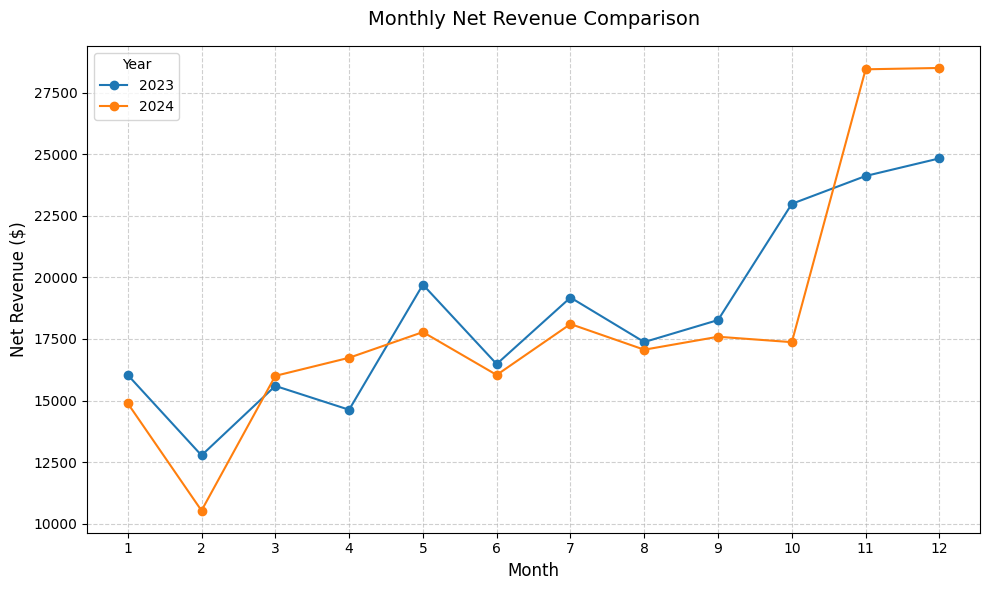

In [30]:
# Monthly Comparison of Net Revenue

#EDA1: Plotting with Matplotlib for revenue
plt.figure(figsize=(10, 6))

# Plot all columns (years) automatically
for year in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[year],
        marker="o",
        label=str(year),
    )

# Formatting the Chart
plt.title("Monthly Net Revenue Comparison", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Net Revenue ($)", fontsize=12)

# Ensure x-axis only shows actual month numbers (1 to 12)
plt.xticks(range(1, 13))

# Add grid and legend to differentiate the years
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Year", fontsize=10)

# Display the plot
plt.tight_layout()
plt.show()



In [31]:
# revenue by order_year_month
#aggregate revenue by year and month
net_revenue_order_year_month=(df.groupby(["order_year_month"])["net_revenue"].sum().reset_index())
net_revenue_order_year_month


,order_year_month,net_revenue
0,2023-01,16039.96
1,2023-02,12775.39
2,2023-03,15594.28
3,2023-04,14627.15
4,2023-05,19705.98
5,2023-06,16482.23
6,2023-07,19182.01
7,2023-08,17375.21
8,2023-09,18268.55
9,2023-10,22985.73


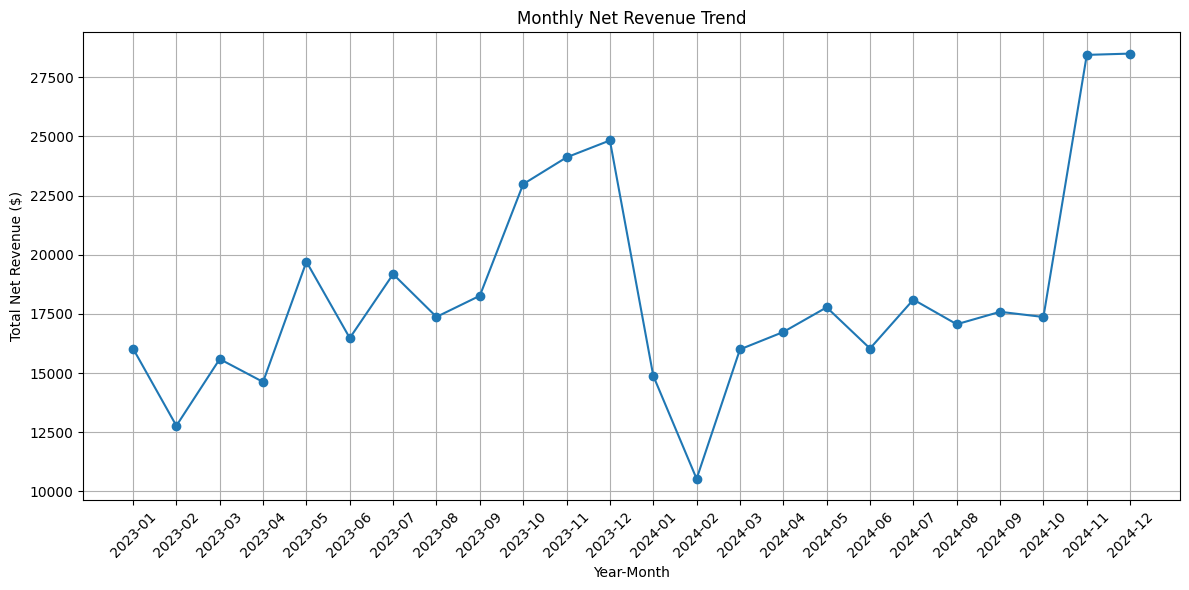

In [32]:
# Trend of Net Revenue over Time
plt.figure(figsize=(12, 6))

plt.plot(net_revenue_order_year_month["order_year_month"], net_revenue_order_year_month["net_revenue"], marker="o")

plt.xlabel("Year-Month")
plt.ylabel("Total Net Revenue ($)")
plt.title("Monthly Net Revenue Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
#assign the specific order of the weekdays in preferred order instead of alphabetical
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]
#initialize the weekday to be default order
net_revenue_weekdays2 = (
    df.groupby('order_weekday')['net_revenue']
       .sum()
       .reset_index()
)
#change the order by specifying the lists of weekdays, to specific order lists,
#make sure it changes so that it is ordered according to the preferred list
net_revenue_weekdays2['order_weekday'] = pd.Categorical(
    net_revenue_weekdays2['order_weekday'],
    categories=weekday_order,
    ordered=True
)

net_revenue_weekdays2 = net_revenue_weekdays2.sort_values('order_weekday')

net_revenue_weekdays2


,order_weekday,net_revenue
1,Monday,60761.92
5,Tuesday,58968.24
6,Wednesday,56042.72
4,Thursday,64208.65
0,Friday,58296.71
2,Saturday,70134.69
3,Sunday,72631.83


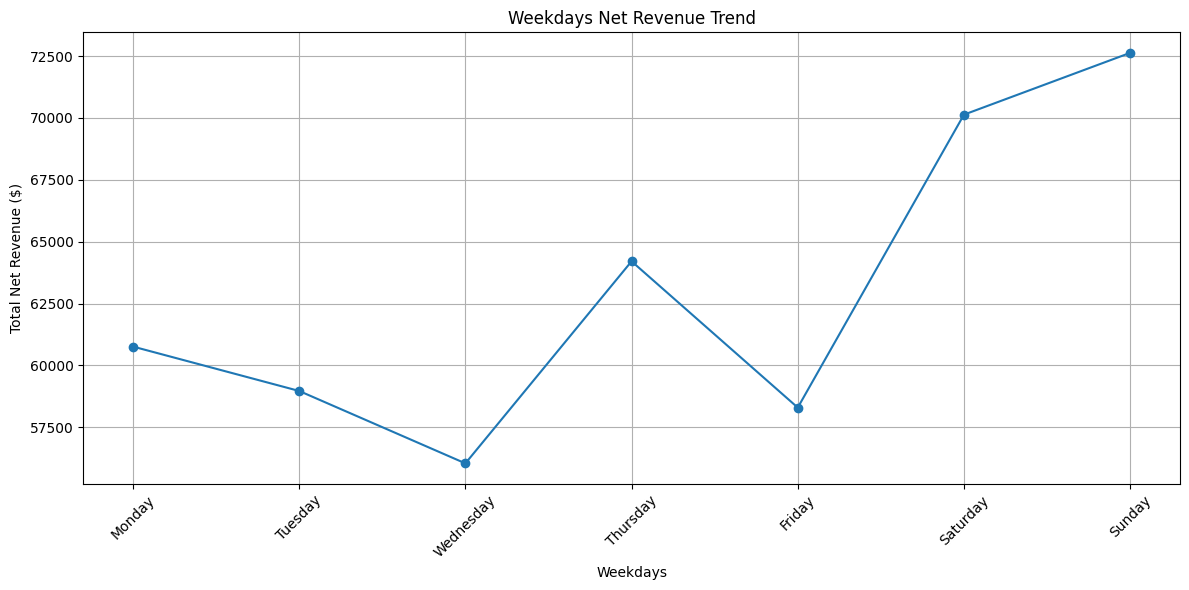

In [34]:
# net_revenue for the order_year_month line graph
plt.figure(figsize=(12, 6))

plt.plot(
    net_revenue_weekdays2["order_weekday"],
    net_revenue_weekdays2["net_revenue"],
    marker="o"
)

plt.xlabel("Weekdays")
plt.ylabel("Total Net Revenue ($)")
plt.title("Weekdays Net Revenue Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
#EDA2: Scatterplot that displays the x-axis for the return rate and y-axis for the revenue
#First, make a summary table
category_summary = (df.groupby('product_category').agg(return_rate=('is_returned', 'mean'),net_revenue=('net_revenue', 'sum')).reset_index())
category_summary['return_rate_pct'] = round((category_summary['return_rate'] * 100),2)
category_summary


,product_category,return_rate,net_revenue,return_rate_pct
0,Automotive,0.202353,16751.75,20.24
1,Beauty,0.170068,29819.41,17.01
2,Books,0.103000,44792.90,10.30
3,Clothing,0.256545,67998.64,25.65
4,Electronics,0.211864,89059.06,21.19
5,Food,0.083832,18376.18,8.38
6,Garden,0.100334,13197.54,10.03
7,Home & Kitchen,0.180471,52174.73,18.05
8,Jewelry,0.149351,6778.34,14.94
9,Music,0.135484,7889.49,13.55


14.56
18376.18


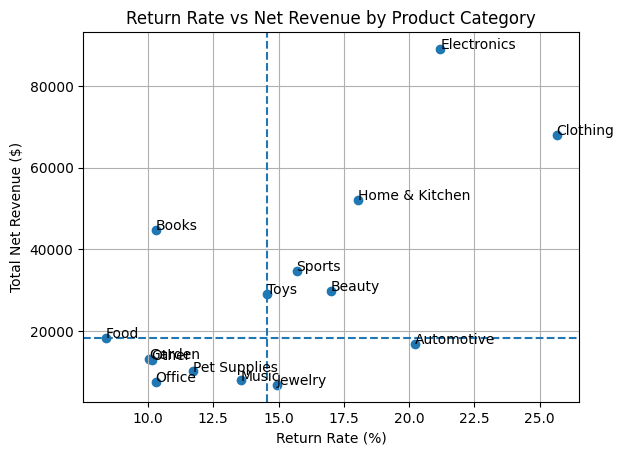

In [36]:
#Plot the scatterplot

plt.scatter(
    category_summary["return_rate_pct"],
    category_summary["net_revenue"]
)

# Add product category labels beside each dot
for i in range(len(category_summary)):
    plt.text(
        category_summary["return_rate_pct"][i],
        category_summary["net_revenue"][i],
        category_summary["product_category"][i]
    )

# Find the median values
median_return = category_summary["return_rate_pct"].median()
median_revenue = category_summary["net_revenue"].median()

print(median_return)
print(median_revenue)

# Add vertical line = median return rate
plt.axvline(
    median_return,
    linestyle="--"
)

# Add horizontal line = median revenue
plt.axhline(
    median_revenue,
    linestyle="--")
# Labels and title
plt.xlabel("Return Rate (%)")
plt.ylabel("Total Net Revenue ($)")
plt.title("Return Rate vs Net Revenue by Product Category")

plt.grid(True)
plt.show()

In [37]:
#EDA2: Scatterplot that displays the x-axis for the return rate and y-axis for the revenue
#First, make a summary table
category_summary_country = (df.groupby('country').agg(return_rate=('is_returned', 'mean'),net_revenue=('net_revenue', 'sum')).reset_index())
category_summary_country['return_rate_pct'] = round((category_summary_country['return_rate'] * 100),2)
category_summary_country

,country,return_rate,net_revenue,return_rate_pct
0,Argentina,0.086957,1143.06,8.70
1,Australia,0.160343,33859.04,16.03
2,Belgium,0.235294,1100.76,23.53
3,Brazil,0.207101,13398.91,20.71
4,Canada,0.172669,46130.71,17.27
5,Denmark,0.533333,514.56,53.33
6,France,0.188854,30774.57,18.89
7,Germany,0.197932,29133.44,19.79
8,India,0.149254,21832.27,14.93
9,Ireland,0.062500,594.19,6.25


17.12
5346.85


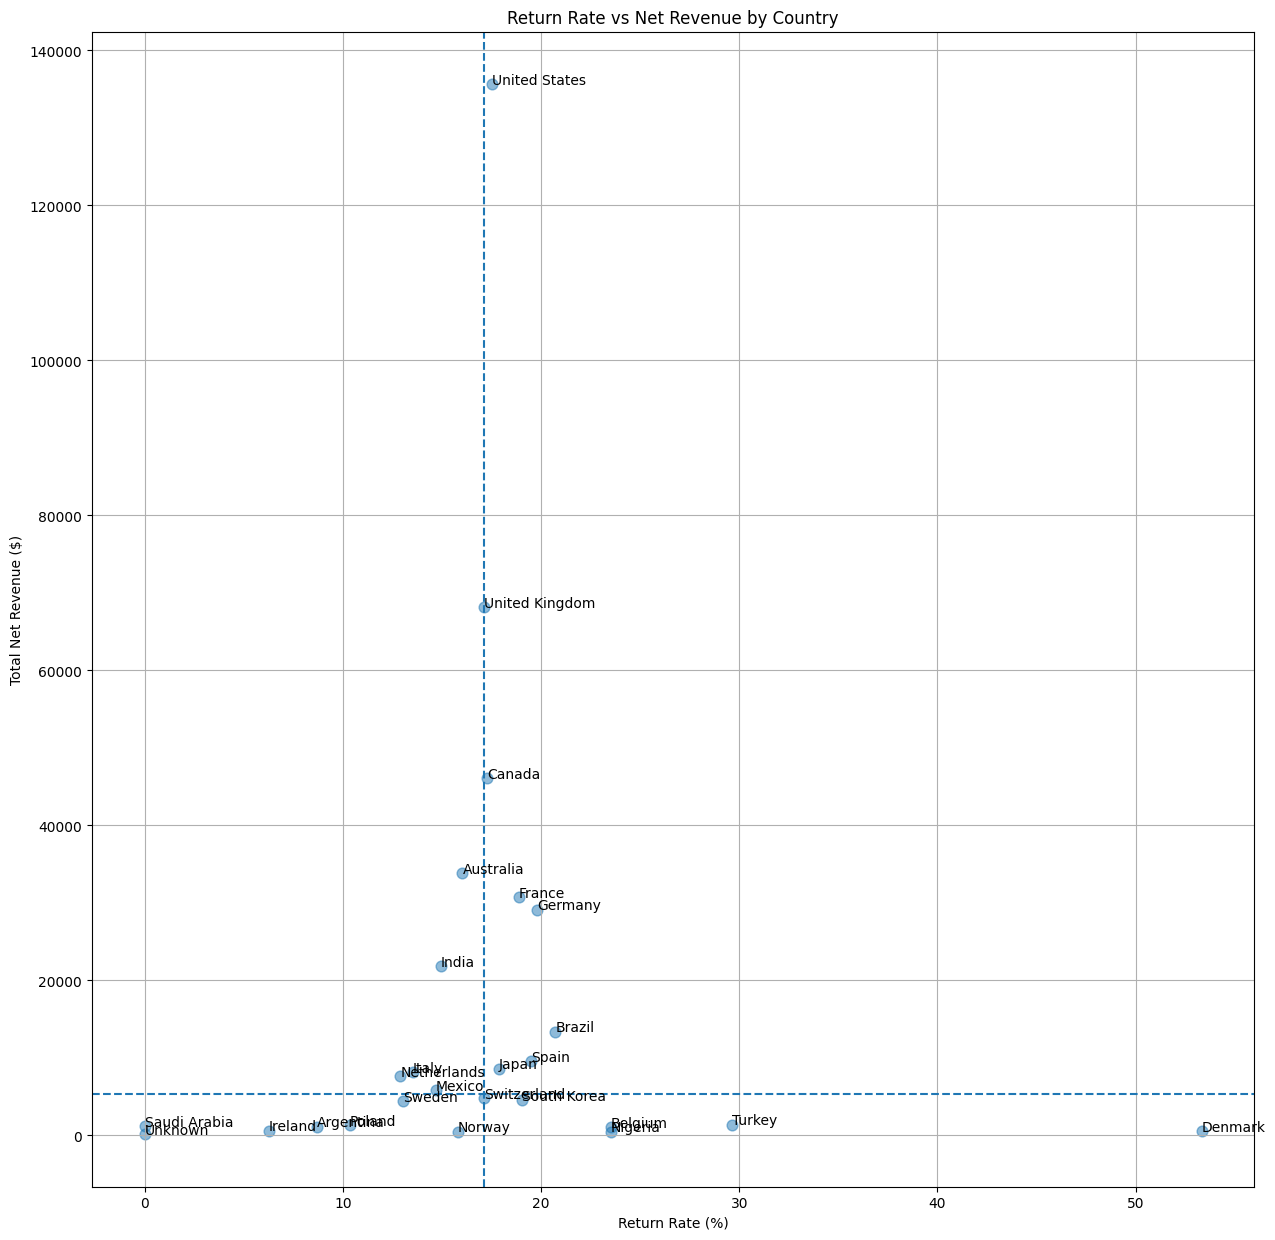

In [38]:
#Plot the scatterplot
#Make the figure size bigger from 12,7 to 15,15 to improve the visibility
plt.figure(figsize=(15,15))
plt.scatter(
    category_summary_country["return_rate_pct"],
    category_summary_country["net_revenue"],
    alpha=0.5,
    s=60
)
#adjusted the s=60 is to make sure its not too large or too small
#adjusted the alpha=0.5 to
#lower the alpha, the more
# Add product category labels beside each dot
for i in range(len(category_summary_country)):
    plt.text(
        category_summary_country["return_rate_pct"][i],
        category_summary_country["net_revenue"][i],
        category_summary_country["country"][i]
    )

# Find the median values
median_return2 = category_summary_country["return_rate_pct"].median()
median_revenue2 = category_summary_country["net_revenue"].median()

print(median_return2)
print(median_revenue2)

# Add vertical line = median return rate
plt.axvline(
    median_return2,
    linestyle="--"
)

# Add horizontal line = median revenue
plt.axhline(
    median_revenue2,
    linestyle="--")
# Labels and title
plt.xlabel("Return Rate (%)")
plt.ylabel("Total Net Revenue ($)")
plt.title("Return Rate vs Net Revenue by Country")

plt.grid(True)
plt.show()

In [39]:
category_summary_country2=category_summary_country[category_summary_country["net_revenue"]>median_revenue2].reset_index(drop=True)
category_summary_country2
#Need to specify reset_index(drop=True) to prevent error where it has (1,3,4,6,7,10,14) just because i filter it based on original dataset
#This will result to a mismatch, say for example the number of rows for the filtered category_summary_country, could be 10, which I will get an error when running
## Add Country labels beside each dot
#shortlist countries with higher revenue which can either have low return rate ( attractive for higher profit)
#but higher reutrn rate as worth investigation to determine the key drivers to prevent loss of earnings
#for i in range(len(category_summary_country2)):
    #plt.text(
        #category_summary_country2["return_rate_pct"][i],
        #category_summary_country2["net_revenue"][i],
        #category_summary_country2["country"][i]
   # )


,country,return_rate,net_revenue,return_rate_pct
0,Australia,0.160343,33859.04,16.03
1,Brazil,0.207101,13398.91,20.71
2,Canada,0.172669,46130.71,17.27
3,France,0.188854,30774.57,18.89
4,Germany,0.197932,29133.44,19.79
5,India,0.149254,21832.27,14.93
6,Italy,0.135266,8183.74,13.53
7,Japan,0.178744,8618.32,17.87
8,Mexico,0.146853,5873.32,14.69
9,Netherlands,0.129032,7668.47,12.90


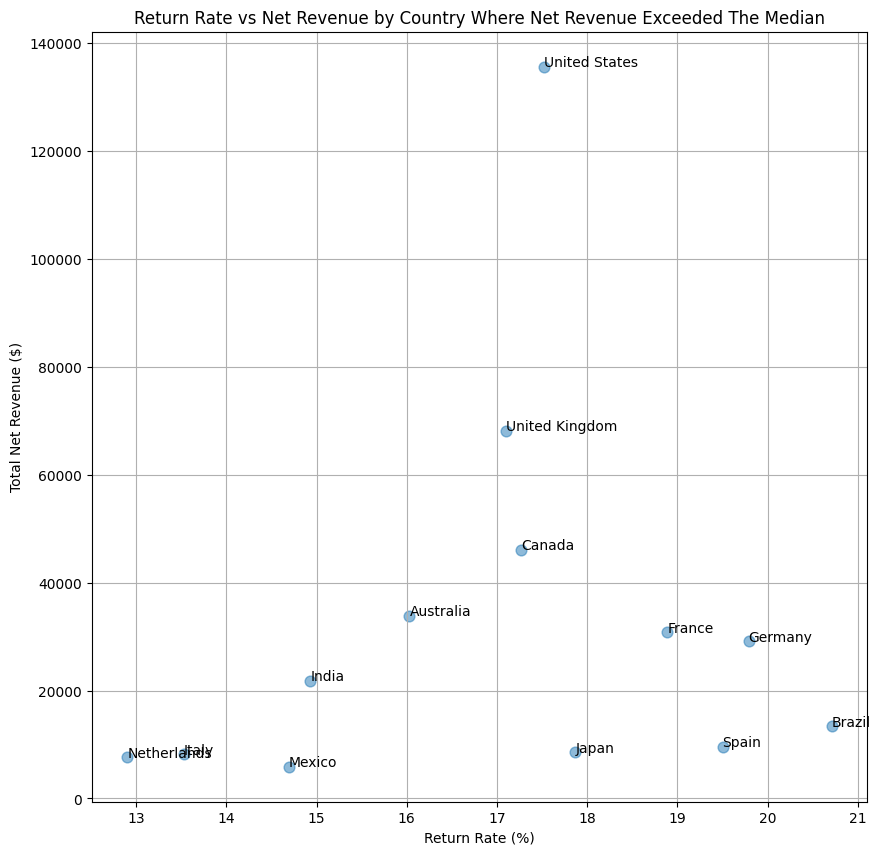

In [40]:
#Plot the scatterplot
#much clearer!!!
plt.figure(figsize=(10,10))
plt.scatter(
    category_summary_country2["return_rate_pct"],
    category_summary_country2["net_revenue"],
    alpha=0.5,
    s=60
)

# Add Country labels beside each dot
for i in range(len(category_summary_country2)):
    plt.text(
        category_summary_country2["return_rate_pct"][i],
        category_summary_country2["net_revenue"][i],
        category_summary_country2["country"][i]
    )

# Labels and title
plt.xlabel("Return Rate (%)")
plt.ylabel("Total Net Revenue ($)")
plt.title("Return Rate vs Net Revenue by Country Where Net Revenue Exceeded The Median")

plt.grid(True)
plt.show()


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

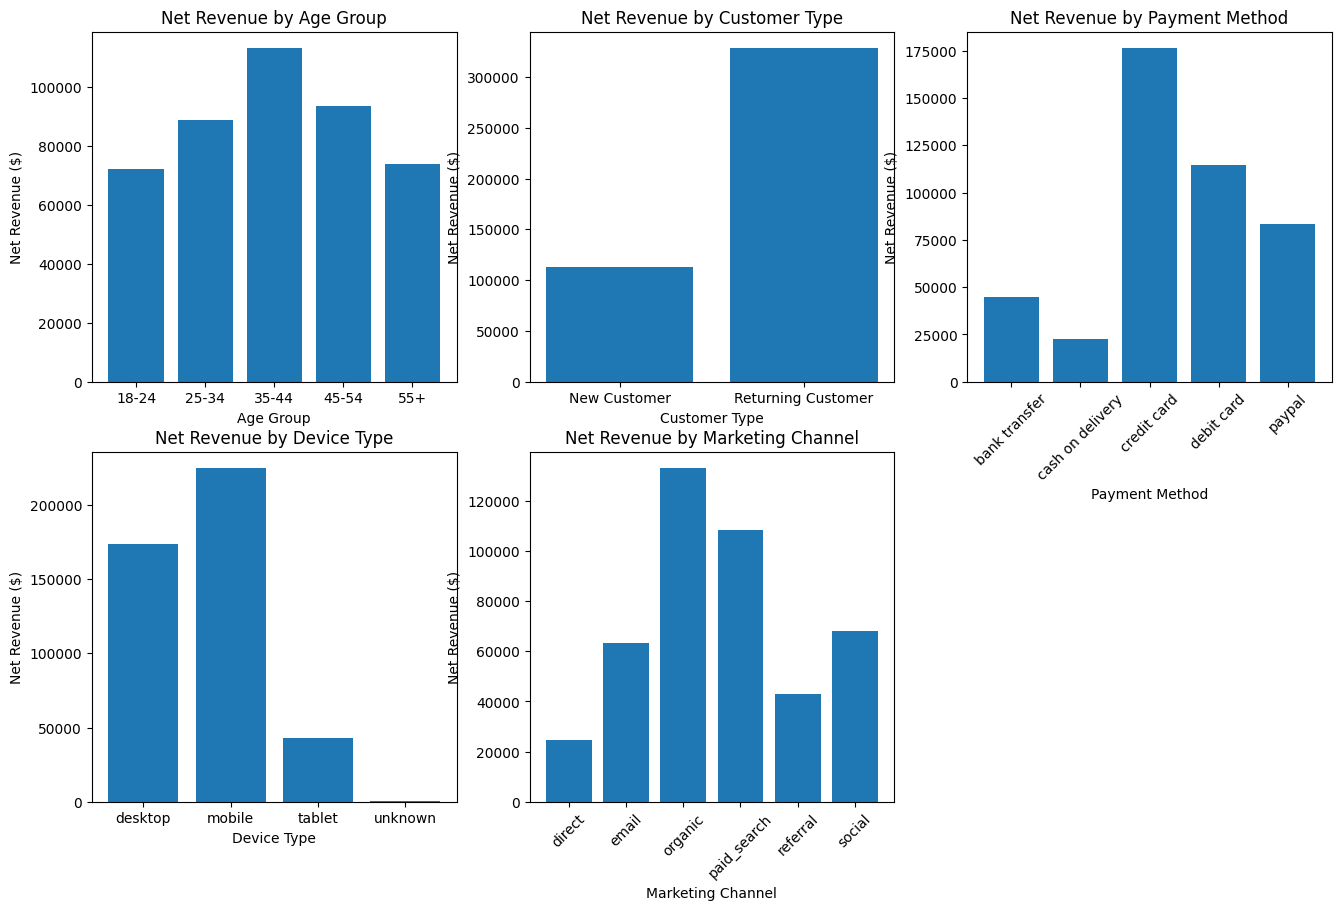

In [41]:
#EDA 3 bar matplotlib charts for the net revenue wrt payment method, marketing channel, device, customer type, age groups
#Excluding countries and product types because the bar chart may get crowded as they have as many as 15 and 26 categories
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Net revenue by age group
age_revenue = df.groupby("age_group", observed=False)["net_revenue"].sum()

axes[0, 0].bar(age_revenue.index, age_revenue.values)
axes[0, 0].set_title("Net Revenue by Age Group")
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Net Revenue ($)")


# 2. Net revenue by customer type
customer_revenue = df.groupby("customer_type")["net_revenue"].sum()

axes[0, 1].bar(customer_revenue.index, customer_revenue.values)
axes[0, 1].set_title("Net Revenue by Customer Type")
axes[0, 1].set_xlabel("Customer Type")
axes[0, 1].set_ylabel("Net Revenue ($)")


# 3. Net revenue by payment method
payment_revenue = df.groupby("payment_method")["net_revenue"].sum()

axes[0, 2].bar(payment_revenue.index, payment_revenue.values)
axes[0, 2].set_title("Net Revenue by Payment Method")
axes[0, 2].set_xlabel("Payment Method")
axes[0, 2].set_ylabel("Net Revenue ($)")
axes[0, 2].tick_params(axis="x", rotation=45)

#do tick_params(axis="x", rotation=45) because I avoid making the categories with longer
#text that could get crowded/overlap with each other otherwise if they were to written below each bar. so< i wanted to make
#it diagonal.

# 4. Net revenue by device type
device_revenue = df.groupby("device_type")["net_revenue"].sum()

axes[1, 0].bar(device_revenue.index, device_revenue.values)
axes[1, 0].set_title("Net Revenue by Device Type")
axes[1, 0].set_xlabel("Device Type")
axes[1, 0].set_ylabel("Net Revenue ($)")


# 5. Net revenue by marketing channel
marketing_revenue = df.groupby("marketing_channel")["net_revenue"].sum()

axes[1, 1].bar(marketing_revenue.index, marketing_revenue.values)
axes[1, 1].set_title("Net Revenue by Marketing Channel")
axes[1, 1].set_xlabel("Marketing Channel")
axes[1, 1].set_ylabel("Net Revenue ($)")
axes[1, 1].tick_params(axis="x", rotation=45)


# Hide unused 6th subplot
axes[1, 2].axis("off")



(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

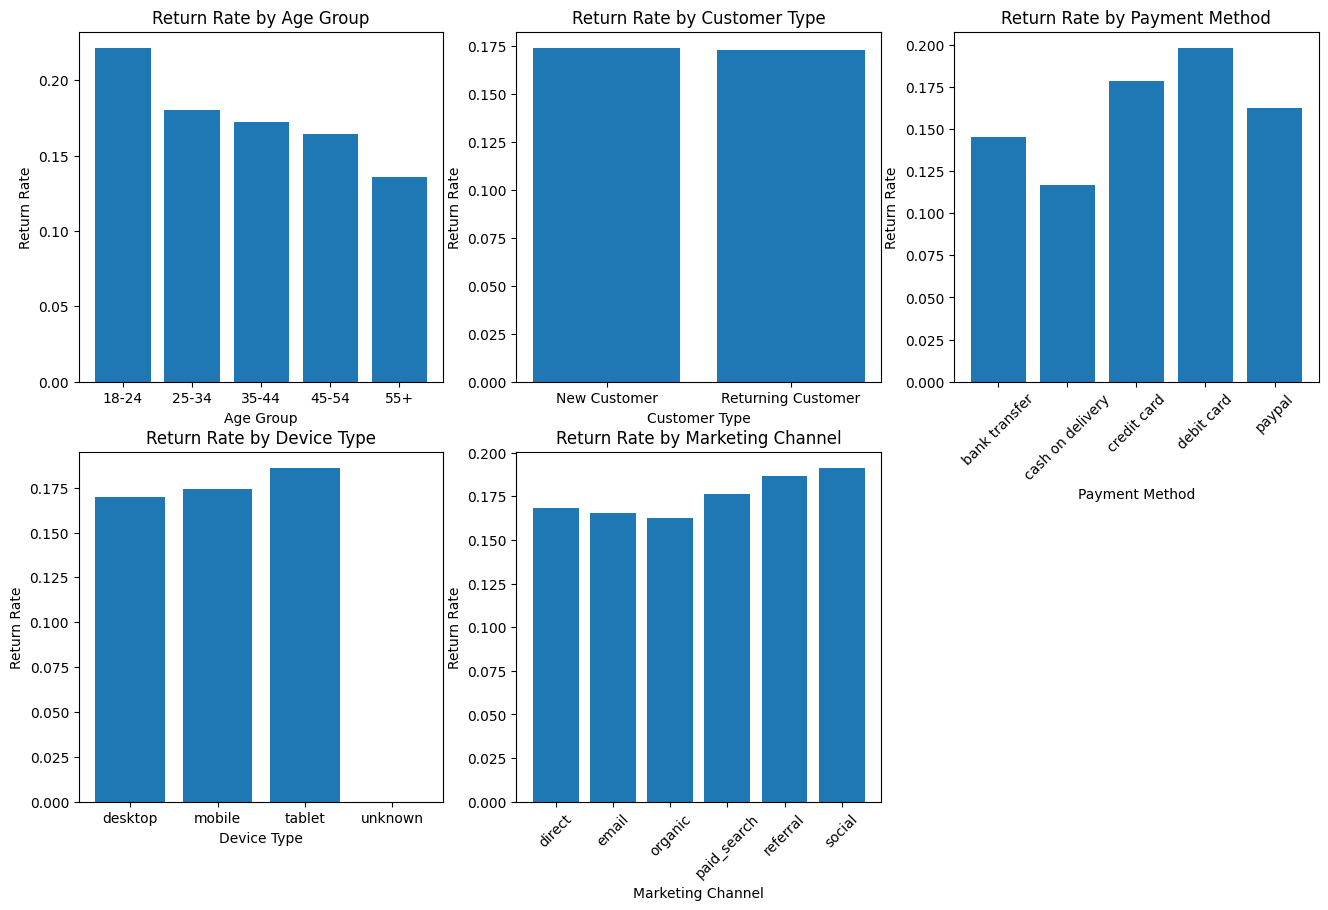

In [42]:
#EDA 3 bar matplotlib charts for the return rate wrt payment method, marketing channel, device, customer type, age groups
#Excluding countries and product types because the bar chart may get crowded as they have as many as 15 and 26 categories
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Net revenue by age group
age_revenue = df.groupby("age_group", observed=False)["is_returned"].mean()

axes[0, 0].bar(age_revenue.index, age_revenue.values)
axes[0, 0].set_title("Return Rate by Age Group")
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Return Rate")


# 2. Net revenue by customer type
customer_revenue = df.groupby("customer_type")["is_returned"].mean()

axes[0, 1].bar(customer_revenue.index, customer_revenue.values)
axes[0, 1].set_title("Return Rate by Customer Type")
axes[0, 1].set_xlabel("Customer Type")
axes[0, 1].set_ylabel("Return Rate")


# 3. Net revenue by payment method
payment_revenue = df.groupby("payment_method")["is_returned"].mean()

axes[0, 2].bar(payment_revenue.index, payment_revenue.values)
axes[0, 2].set_title("Return Rate by Payment Method")
axes[0, 2].set_xlabel("Payment Method")
axes[0, 2].set_ylabel("Return Rate")
axes[0, 2].tick_params(axis="x", rotation=45)

#do tick_params(axis="x", rotation=45) because I avoid making the categories with longer
#text that could get crowded/overlap with each other otherwise if they were to written below each bar. so< i wanted to make
#it diagonal.

# 4. Net revenue by device type
device_revenue = df.groupby("device_type")["is_returned"].mean()

axes[1, 0].bar(device_revenue.index, device_revenue.values)
axes[1, 0].set_title("Return Rate by Device Type")
axes[1, 0].set_xlabel("Device Type")
axes[1, 0].set_ylabel("Return Rate")


# 5. Net revenue by marketing channel
marketing_revenue = df.groupby("marketing_channel")["is_returned"].mean()

axes[1, 1].bar(marketing_revenue.index, marketing_revenue.values)
axes[1, 1].set_title("Return Rate by Marketing Channel")
axes[1, 1].set_xlabel("Marketing Channel")
axes[1, 1].set_ylabel("Return Rate")
axes[1, 1].tick_params(axis="x", rotation=45)


# Hide unused 6th subplot
axes[1, 2].axis("off")

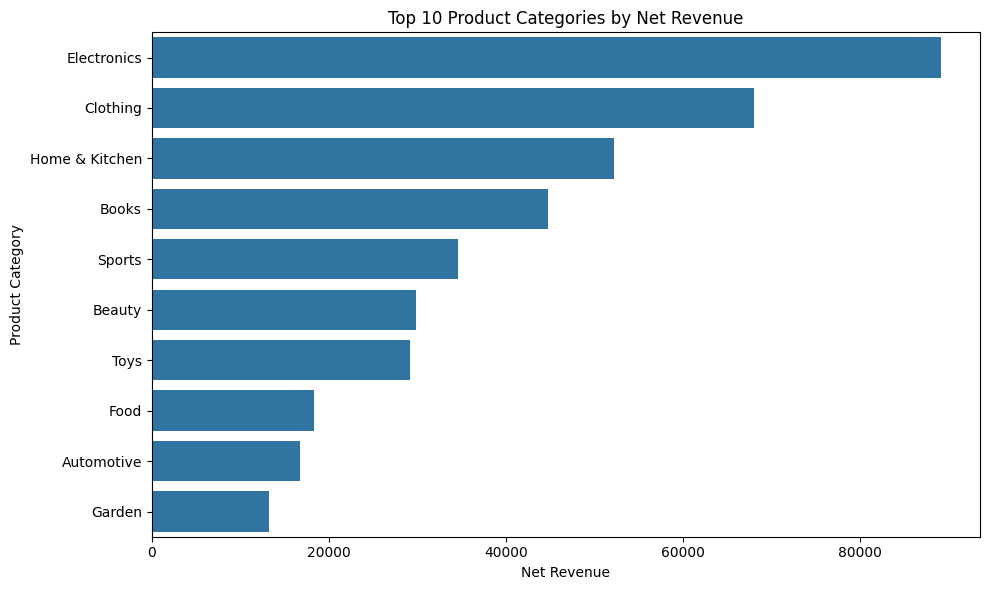

<class 'function'>


In [43]:
import seaborn as sns
top10 = (
    df.groupby("product_category")["net_revenue"]
       .sum()
       .nlargest(10)
       .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="net_revenue",
    y="product_category"
)

plt.title("Top 10 Product Categories by Net Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

print(type(plt.title))

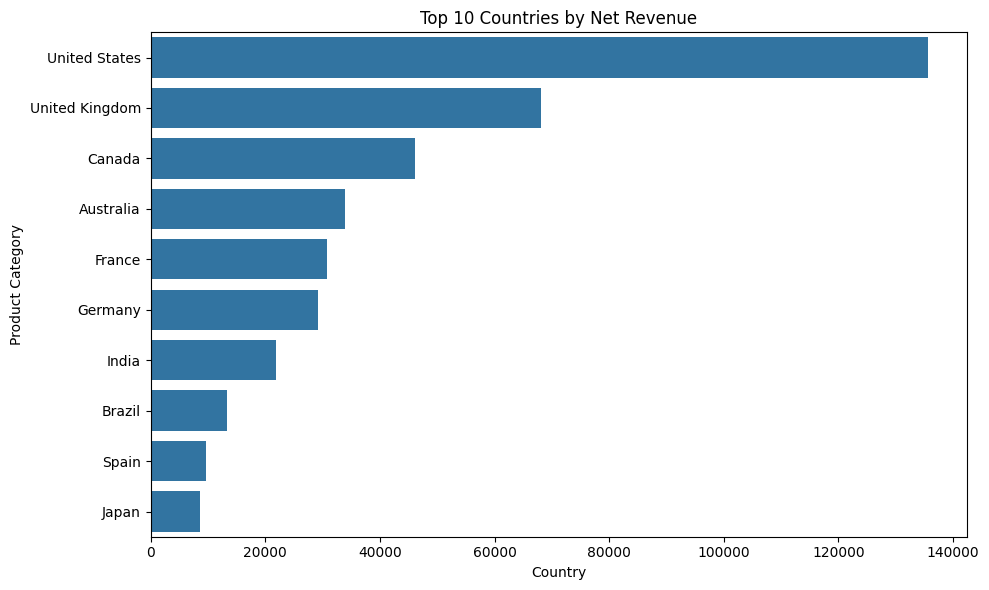

<class 'function'>


In [44]:
top10Country = (
    df.groupby("country")["net_revenue"]
       .sum()
       .nlargest(10)
       .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10Country,
    x="net_revenue",
    y="country"
)

plt.title("Top 10 Countries by Net Revenue")
plt.xlabel("Country")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

print(type(plt.title))

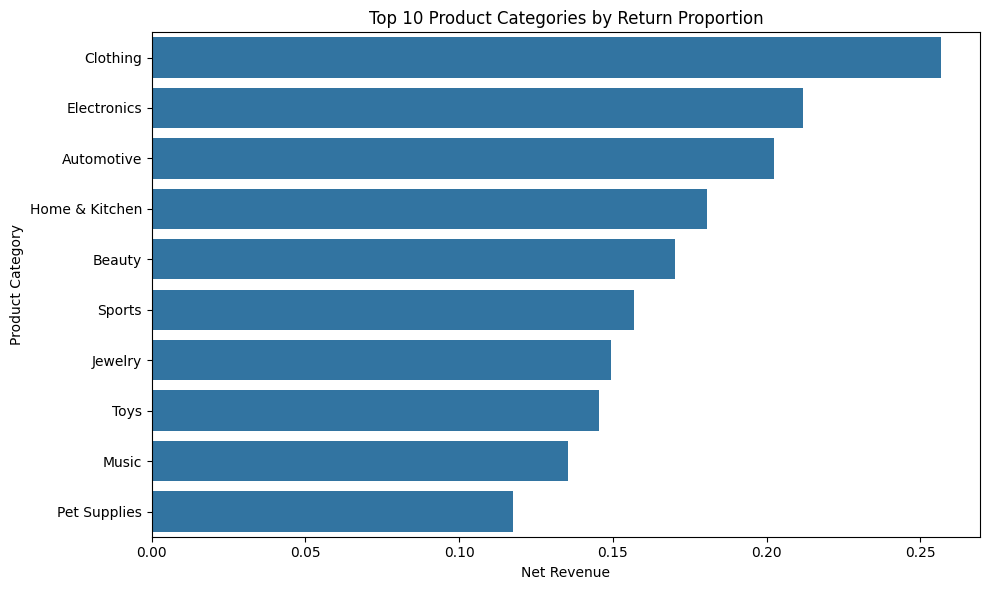

<class 'function'>


In [45]:
import seaborn as sns
top10return = (
    df.groupby("product_category")["is_returned"]
       .mean()
       .nlargest(10)
       .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10return,
    x="is_returned",
    y="product_category"
)

plt.title("Top 10 Product Categories by Return Proportion")
plt.xlabel("Net Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

print(type(plt.title))

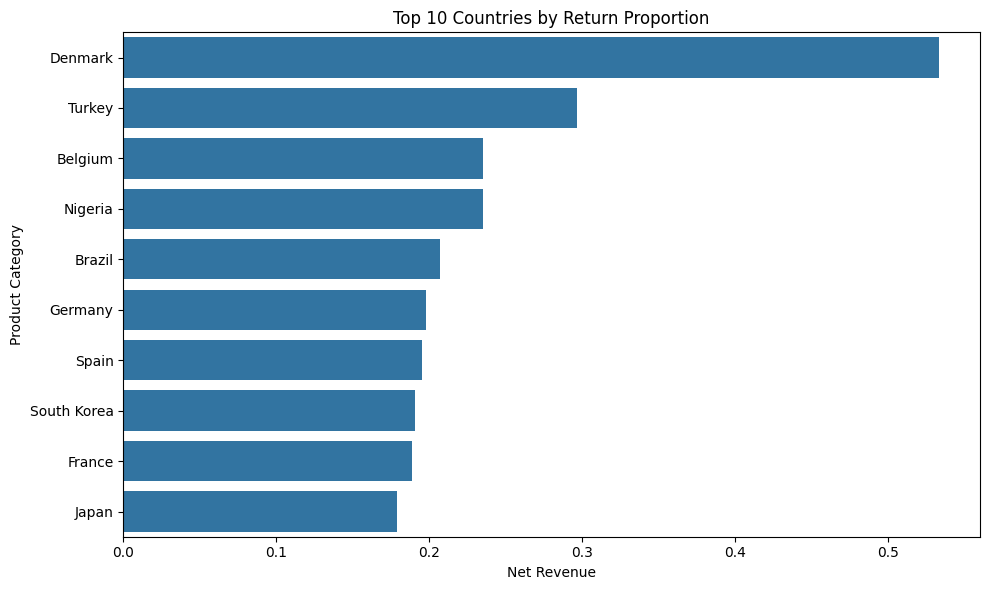

<class 'function'>


In [46]:
top10returncountry = (
    df.groupby("country")["is_returned"]
       .mean()
       .nlargest(10)
       .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10returncountry,
    x="is_returned",
    y="country"
)

plt.title("Top 10 Countries by Return Proportion")
plt.xlabel("Net Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

print(type(plt.title))

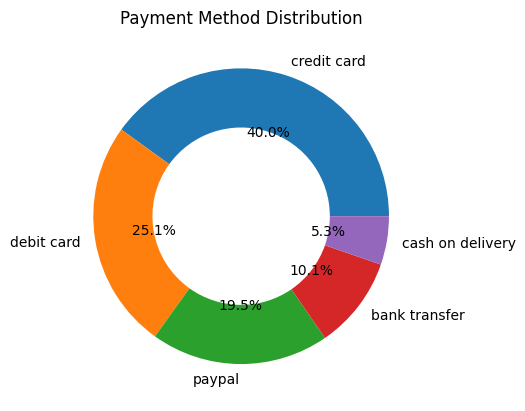

In [47]:
#donut chart
counts = df["payment_method"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%",
        wedgeprops={"width": 0.4})
plt.title("Payment Method Distribution")
plt.show()

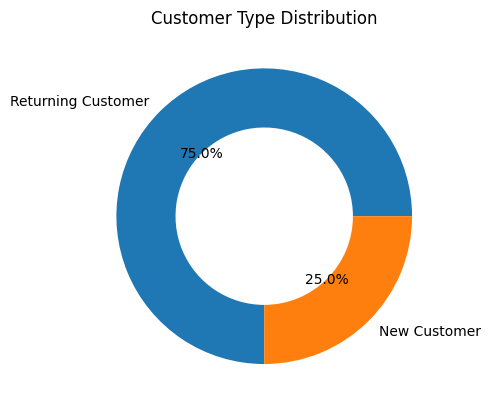

In [48]:
counts2 = df["customer_type"].value_counts()

plt.pie(counts2, labels=counts2.index, autopct="%1.1f%%",
        wedgeprops={"width": 0.4})
plt.title("Customer Type Distribution")
plt.show()

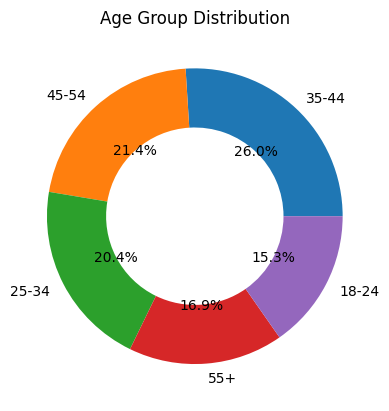

In [49]:
counts3 = df["age_group"].value_counts()

plt.pie(counts3, labels=counts3.index, autopct="%1.1f%%",
        wedgeprops={"width": 0.4})
plt.title("Age Group Distribution")
plt.show()

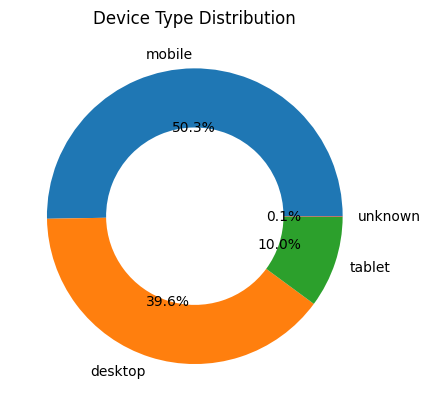

In [50]:
counts4 = df["device_type"].value_counts()

plt.pie(counts4, labels=counts4.index, autopct="%1.1f%%",
        wedgeprops={"width": 0.4})
plt.title("Device Type Distribution")
plt.show()

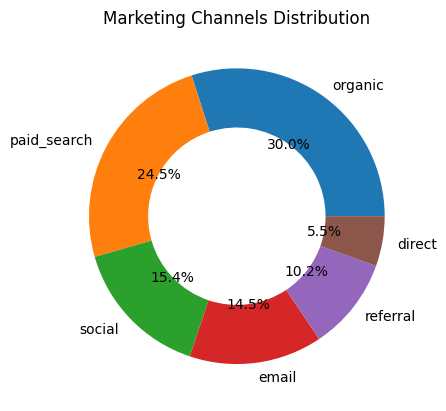

In [51]:

counts5 = df["marketing_channel"].value_counts()

plt.pie(counts5, labels=counts5.index, autopct="%1.1f%%",
        wedgeprops={"width": 0.4})
plt.title("Marketing Channels Distribution")
plt.show()

# **Interactive Dashboard through Dash and Plotly**

In [52]:
import sys
!{sys.executable} -m pip install plotly dash
import plotly.express as px
from dash import Dash, dcc, html, Input, Output, dash_table

df.reset_index(inplace=True)
#df.drop(columns=["level_0"], inplace=True, axis=1)

# Load the cleaned DataFrame
# df = pd.read_csv("ecommerce_orders_cleaned.csv")
#df["order_date"] = pd.to_datetime(df["order_date"])

MIN_DATE = df["order_date"].min()
MAX_DATE = df["order_date"].max()
CATEGORIES = sorted(df["product_category"].unique())
COUNTRIES = sorted(df["country"].unique())
CHANNELS = sorted(df["marketing_channel"].unique())
COLORWAY = px.colors.qualitative.Set2

# create a dash application
app = Dash(__name__)
app.title = "Ecommerce Orders Dashboard"

CARD_STYLE = {
    "background": "#ffffff", "borderRadius": "10px", "padding": "16px 20px",
    "boxShadow": "0 1px 4px rgba(0,0,0,0.08)", "flex": "1", "minWidth": "180px",
}

# build dash app layout
app.layout = html.Div(
    style={"fontFamily": "Inter, Arial, sans-serif", "background": "#f4f6f8", "padding": "24px"},
    children=[
        html.H1("Ecommerce Orders Dashboard", style={"marginBottom": "4px"}), # the title will go here in the html.h1 you can style the text
        html.P("Explore revenue, returns, and customer behavior across products, countries, "
               "and marketing channels.", style={"color": "#555", "marginTop": "0"}),

        html.Div(style={"display": "flex", "flexWrap": "wrap", "gap": "16px", "background": "#fff",
                         "padding": "16px", "borderRadius": "10px", "boxShadow": "0 1px 4px rgba(0,0,0,0.08)",
                         "marginBottom": "20px"},
            children=[
                html.Div(style={"flex": "1", "minWidth": "260px"}, children=[
                    html.Label("Date range"), # this is the first html division which we refer to as dcc
                    dcc.DatePickerRange(id="date-range", min_date_allowed=MIN_DATE, max_date_allowed=MAX_DATE,
                                         start_date=MIN_DATE, end_date=MAX_DATE),
                ]),
                html.Div(style={"flex": "1", "minWidth": "220px"}, children=[
                    html.Label("Product category"), # this is the first html division which we refer to as dcc
                    dcc.Dropdown(id="category-filter", options=[{"label": c, "value": c} for c in CATEGORIES],
                                 multi=True, placeholder="All categories"),
                ]),
                html.Div(style={"flex": "1", "minWidth": "220px"}, children=[
                    html.Label("Country"), # this is the first html division which we refer to as dcc
                    dcc.Dropdown(id="country-filter", options=[{"label": c, "value": c} for c in COUNTRIES],
                                 multi=True, placeholder="All countries"),
                ]),
                html.Div(style={"flex": "1", "minWidth": "220px"}, children=[
                    html.Label("Marketing channel"), # this is the first html division which we refer to as dcc
                    dcc.Dropdown(id="channel-filter", options=[{"label": c, "value": c} for c in CHANNELS],
                                 multi=True, placeholder="All channels"),
                ]),
            ]),

        html.Div(id="kpi-row", style={"display": "flex", "flexWrap": "wrap", "gap": "16px", "marginBottom": "20px"}),

        html.Div(style={"display": "flex", "flexWrap": "wrap", "gap": "16px", "marginBottom": "16px"}, children=[
            html.Div(dcc.Graph(id="revenue-trend"), style={**CARD_STYLE, "minWidth": "460px"}), #use dcc.graph tag for including the plot and give each plot an ID
            html.Div(dcc.Graph(id="category-bar"), style={**CARD_STYLE, "minWidth": "380px"}), #use dcc.graph tag for including the plot and give each plot an ID
        ]),
        html.Div(style={"display": "flex", "flexWrap": "wrap", "gap": "16px", "marginBottom": "16px"}, children=[
            html.Div(dcc.Graph(id="country-map"), style={**CARD_STYLE, "minWidth": "460px"}),
            html.Div(dcc.Graph(id="channel-pie"), style={**CARD_STYLE, "minWidth": "380px"}),
        ]),
        html.Div(style={"display": "flex", "flexWrap": "wrap", "gap": "16px", "marginBottom": "16px"}, children=[
            html.Div(dcc.Graph(id="return-rate-bar"), style={**CARD_STYLE, "minWidth": "380px"}),
            html.Div(dcc.Graph(id="aov-histogram"), style={**CARD_STYLE, "minWidth": "380px"}),
            html.Div(dcc.Graph(id="device-payment-heatmap"), style={**CARD_STYLE, "minWidth": "380px"}),
        ]),

        html.Div(style=CARD_STYLE, children=[
            html.H3("Order details (filtered)"),
            dash_table.DataTable(
                id="orders-table",
                columns=[{"name": c, "id": c} for c in
                         ["order_id", "order_date", "product_category", "country",
                          "payment_method", "quantity", "order_total", "is_returned"]],
                page_size=10, sort_action="native", filter_action="native",
                style_table={"overflowX": "auto"},
                style_cell={"padding": "6px", "fontFamily": "Inter, Arial, sans-serif", "fontSize": "13px"},
                style_header={"fontWeight": "bold", "backgroundColor": "#f0f2f5"},
            ),
        ]),
    ],
)


def filter_df(start_date, end_date, categories, countries, channels):
    dff = df[(df["order_date"] >= start_date) & (df["order_date"] <= end_date)]
    if categories:
        dff = dff[dff["product_category"].isin(categories)]
    if countries:
        dff = dff[dff["country"].isin(countries)]
    if channels:
        dff = dff[dff["marketing_channel"].isin(channels)]
    return dff


def kpi_card(label, value):
    return html.Div(style=CARD_STYLE, children=[
        html.Div(label, style={"color": "#888", "fontSize": "13px"}),
        html.Div(value, style={"fontSize": "24px", "fontWeight": "700", "marginTop": "4px"}),
    ])

#whenever there's a change in the input component value, the callback function wrapped by the decorator @app.callback is called followed by the update to the
#output component children in the application layout
@app.callback(
    Output("kpi-row", "children"), Output("revenue-trend", "figure"), Output("category-bar", "figure"),
    Output("country-map", "figure"), Output("channel-pie", "figure"), Output("return-rate-bar", "figure"),
    Output("aov-histogram", "figure"), Output("device-payment-heatmap", "figure"), Output("orders-table", "data"),
    Input("date-range", "start_date"), Input("date-range", "end_date"), Input("category-filter", "value"),
    Input("country-filter", "value"), Input("channel-filter", "value"),
)
def update_dashboard(start_date, end_date, categories, countries, channels):
    dff = filter_df(start_date, end_date, categories, countries, channels)

    total_orders = len(dff)
    total_revenue = dff["net_revenue"].sum()
    aov = dff["order_total"].mean() if total_orders else 0
    return_rate = dff["is_returned"].mean() if total_orders else 0
    kpis = [
        kpi_card("Orders", f"{total_orders:,}"),
        kpi_card("Net Revenue", f"${total_revenue:,.0f}"),
        kpi_card("Avg Order Value", f"${aov:,.2f}"),
        kpi_card("Return Rate", f"{return_rate:.1%}"),
        kpi_card("Unique Customers", f"{dff['customer_id'].nunique():,}"),
    ]

    trend = dff.groupby(dff["order_date"].dt.to_period("M"))["net_revenue"].sum().reset_index()
    trend["order_date"] = trend["order_date"].astype(str)
    fig_trend = px.line(trend, x="order_date", y="net_revenue", markers=True,
                         title="Monthly Net Revenue", color_discrete_sequence=COLORWAY)
    fig_trend.update_layout(xaxis_title="Month", yaxis_title="Net revenue ($)")

    cat = dff.groupby("product_category")["net_revenue"].sum().sort_values().reset_index()
    fig_cat = px.bar(cat, x="net_revenue", y="product_category", orientation="h",
                      title="Revenue by Category", color_discrete_sequence=COLORWAY)
    fig_cat.update_layout(xaxis_title="Net revenue ($)", yaxis_title="")

    geo = dff.groupby("country")["net_revenue"].sum().reset_index()
    geo = geo[geo["country"] != "Unknown"]
    fig_map = px.choropleth(geo, locations="country", locationmode="country names", color="net_revenue",
                             title="Revenue by Country", color_continuous_scale="Blues")

    chan = dff.groupby("marketing_channel")["net_revenue"].sum().reset_index()
    fig_channel = px.pie(chan, names="marketing_channel", values="net_revenue",
                          title="Revenue Share by Marketing Channel", hole=0.4, color_discrete_sequence=COLORWAY)

    ret = dff.groupby("product_category")["is_returned"].mean().sort_values().reset_index()
    fig_return = px.bar(ret, x="is_returned", y="product_category", orientation="h",
                         title="Return Rate by Category", color_discrete_sequence=["#e76f51"])
    fig_return.update_layout(xaxis_title="Return rate", xaxis_tickformat=".0%", yaxis_title="")

    fig_hist = px.histogram(dff, x="order_total", nbins=40, title="Order Value Distribution",
                             color_discrete_sequence=COLORWAY)
    fig_hist.update_layout(xaxis_title="Order total ($)", yaxis_title="Number of orders")

    pivot = dff.pivot_table(index="device_type", columns="payment_method", values="order_total", aggfunc="mean")
    fig_heat = px.imshow(pivot, text_auto=".0f", aspect="auto", color_continuous_scale="Blues",
                          title="Avg Order Value: Device x Payment Method")
    fig_heat.update_layout(xaxis_title="Payment method", yaxis_title="Device")

    for fig in [fig_trend, fig_cat, fig_map, fig_channel, fig_return, fig_hist, fig_heat]:
        fig.update_layout(margin=dict(l=10, r=10, t=50, b=10), paper_bgcolor="white")

    table_data = dff.sort_values("order_date", ascending=False).head(500)
    table_data = table_data.assign(order_date=table_data["order_date"].dt.strftime("%Y-%m-%d"))
    table_data = table_data[["order_id", "order_date", "product_category", "country", "payment_method",
                              "quantity", "order_total", "is_returned"]].to_dict("records")

    return kpis, fig_trend, fig_cat, fig_map, fig_channel, fig_return, fig_hist, fig_heat, table_data


# Runs inline in this notebook cell. Switch to jupyter_mode="external", debug=False
# for a clickable proxied URL in its own browser tab instead.
app.run(jupyter_mode="external", debug=True, height=1200)

Dash app running on:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>